In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, RationalQuadratic, WhiteKernel, Matern, ExpSineSquared
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import Kernel
from sklearn.metrics.pairwise import polynomial_kernel
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")





In [2]:
# Read the data
df = pd.read_csv("NoD_to_NCD.csv")

In [3]:
df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,SDG_SH_DTH_RNCOM,Number of deaths attributed to non-communicabl...,numeric,SEAR,South-East Asia,Country,TLS,Timor-Leste,Year,2019,...,NaN,NaN,49.54,NaN,167.8,100 [50-168],NaN,NaN,EN,2021-02-09T00:00:00.000Z
1,SDG_SH_DTH_RNCOM,Number of deaths attributed to non-communicabl...,numeric,SEAR,South-East Asia,Country,BTN,Bhutan,Year,2019,...,NaN,NaN,56.06,NaN,163.0,100 [56-163],NaN,NaN,EN,2021-02-09T00:00:00.000Z
2,SDG_SH_DTH_RNCOM,Number of deaths attributed to non-communicabl...,numeric,EUR,Europe,Country,MNE,Montenegro,Year,2019,...,NaN,NaN,63.92,NaN,145.0,100 [64-145],NaN,NaN,EN,2021-02-09T00:00:00.000Z
3,SDG_SH_DTH_RNCOM,Number of deaths attributed to non-communicabl...,numeric,AFR,Africa,Country,SYC,Seychelles,Year,2019,...,NaN,NaN,66.17,NaN,144.1,100 [66-144],NaN,NaN,EN,2021-02-09T00:00:00.000Z
4,SDG_SH_DTH_RNCOM,Number of deaths attributed to non-communicabl...,numeric,AFR,Africa,Country,LSO,Lesotho,Year,2019,...,NaN,NaN,580.00,NaN,1612.0,1003 [580-1612],NaN,NaN,EN,2021-02-09T00:00:00.000Z


In [4]:
df_P = pd.read_csv("Population.csv")
df_P.head()

,Data Source,World Development Indicators,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last Updated Date,6/28/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Country Name,Country Code,Indicator Name,Indicator Code,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,...,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
4,Aruba,ABW,"Population, total",SP.POP.TOTL,54608.0,55811.0,56682.0,57475.0,58178.0,58782.0,...,103594.0,104257.0,104874.0,105439.0,105962.0,106442.0,106585.0,106537.0,106445.0,106277.0


In [5]:
df.isna().sum()

IndicatorCode                     0
Indicator                         0
ValueType                         0
ParentLocationCode                0
ParentLocation                    0
Location type                     0
SpatialDimValueCode               0
Location                          0
Period type                       0
Period                            0
IsLatestYear                      0
Dim1 type                         0
Dim1                              0
Dim1ValueCode                     0
Dim2 type                         0
Dim2                              0
Dim2ValueCode                     0
Dim3 type                     43920
Dim3                          43920
Dim3ValueCode                 43920
DataSourceDimValueCode        43920
DataSource                    43920
FactValueNumericPrefix        43920
FactValueNumeric                  0
FactValueUoM                  43920
FactValueNumericLowPrefix     43920
FactValueNumericLow               0
FactValueNumericHighPrefix  

In [6]:
# find the duplicates (excluding the first occurrence)

duplicates_except_first = df.duplicated(keep='first')
print("\nDuplicates Except First Occurrence:")
print(df[duplicates_except_first])


Duplicates Except First Occurrence:
Empty DataFrame
Columns: [IndicatorCode, Indicator, ValueType, ParentLocationCode, ParentLocation, Location type, SpatialDimValueCode, Location, Period type, Period, IsLatestYear, Dim1 type, Dim1, Dim1ValueCode, Dim2 type, Dim2, Dim2ValueCode, Dim3 type, Dim3, Dim3ValueCode, DataSourceDimValueCode, DataSource, FactValueNumericPrefix, FactValueNumeric, FactValueUoM, FactValueNumericLowPrefix, FactValueNumericLow, FactValueNumericHighPrefix, FactValueNumericHigh, Value, FactValueTranslationID, FactComments, Language, DateModified]
Index: []

[0 rows x 34 columns]


In [7]:
# Remove the first three rows, including the header row
df_P_updated = df_P.drop(index=[0, 1, 2])

# Reset index to start from 0 again
df_P_updated.reset_index(drop=True, inplace=True)

# Set the fourth row as the header
df_P_updated.columns = df_P_updated.iloc[0]
df_P_updated = df_P_updated.drop(index=0)

# Reset index again to clean up
df_P_updated.reset_index(drop=True, inplace=True)

# Convert column names to strings first
df_P_updated.columns = df_P_updated.columns.astype(str)

# Convert year columns to integers to match 'Period' in NoD_to_NCD.csv
df_P_updated.columns = [int(float(col)) if col.replace('.', '', 1).isdigit() else col for col in df_P_updated.columns]

# Convert the list of years to integers as well
years = list(range(2000, 2020))

# Select the required columns
df2_P = df_P_updated[['Country Name'] + years]

In [8]:
# Define the countries and their colors
countries = ['China', 'United Kingdom of Great Britain and Northern Ireland', 'Nigeria', 'Bangladesh', 'Sri Lanka']
colors = ['#0072B2', '#D55E00', '#009E73', '#999999', '#CC79A7']

# Shortened country names for legend display
country_short_names = {
    'China': 'China',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Nigeria': 'Nigeria',
    'Bangladesh': 'Bangladesh',
    'Sri Lanka': 'Sri Lanka'
}


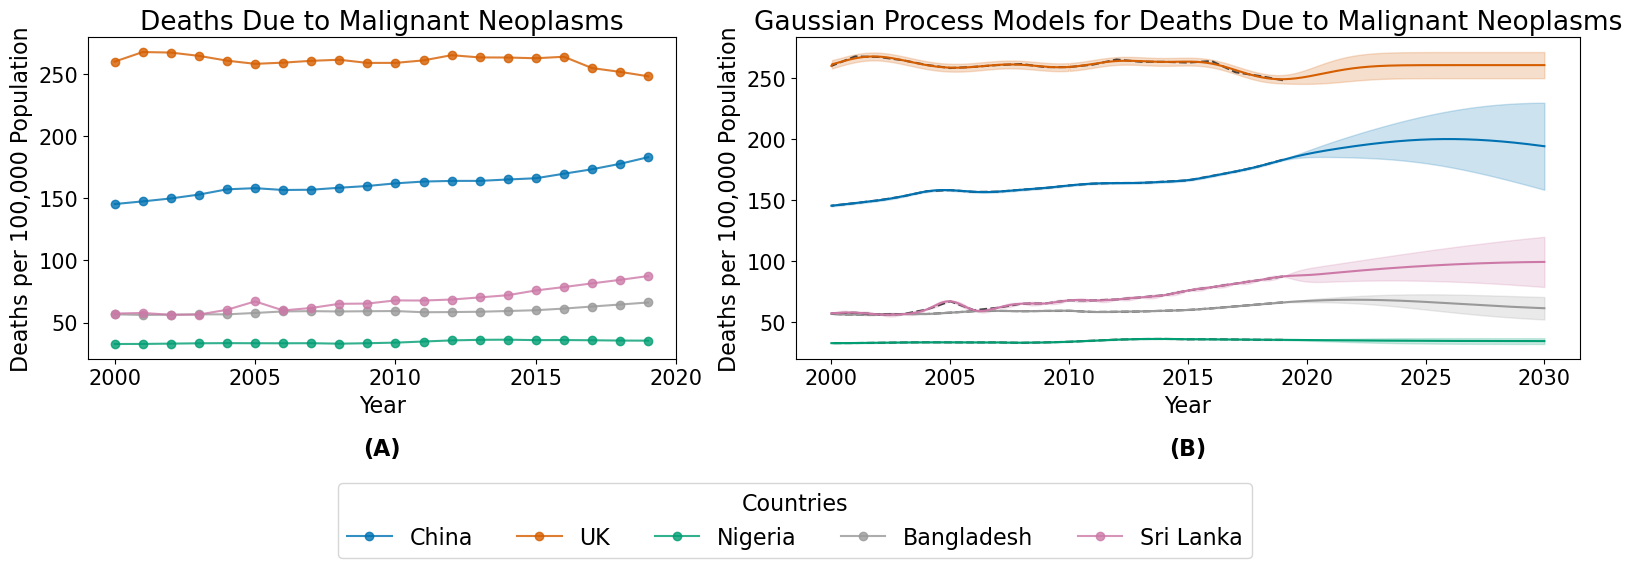

In [14]:
import warnings
warnings.filterwarnings("ignore")

disease = 'Malignant neoplasms'

def plot_measurements(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[(df['Dim1'] == 'Both sexes') & (df['Dim2'] == disease) & (df['Location'] == country)]
    
    # Ensure 'Period' is of type string for merging
    filtered_data = filtered_data.copy()
    filtered_data['Period'] = filtered_data['Period'].astype(str)
    filtered_data_pln = pd.melt(filtered_data_pln, id_vars=['Country Name'], var_name='Year', value_name='Population')
    
    # Convert 'Year' to string for consistency in merging
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)
    
    # Merge population data with the main data
    merged_data = filtered_data.merge(filtered_data_pln, left_on=['Location', 'Period'], right_on=['Country Name', 'Year'])

    # Check if merged data is empty
    if merged_data.empty:
        print(f"No data for {country}")
        return

    # Calculate 'FactValueNumeric' per 100,000 population
    merged_data['FactValuePer100k'] = (merged_data['FactValueNumeric'] / merged_data['Population'].astype(float)) * 100000

    # Plot the results
    ax.plot(merged_data['Period'].astype(float), merged_data['FactValuePer100k'], color=color, label=f'{country}', marker='o', linestyle='-', alpha=0.8)

def plot_gp_regression(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[(df['Dim1'] == 'Both sexes') & (df['Dim2'] == disease) & (df['Location'] == country)]
    
    # Ensure 'Period' is of type string for merging
    filtered_data = filtered_data.copy()
    filtered_data['Period'] = filtered_data['Period'].astype(str)
    filtered_data_pln = pd.melt(filtered_data_pln, id_vars=['Country Name'], var_name='Year', value_name='Population')
    
    # Convert 'Year' to string for consistency in merging
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)
    
    # Merge population data with the main data
    merged_data = filtered_data.merge(filtered_data_pln, left_on=['Location', 'Period'], right_on=['Country Name', 'Year'])

    # Check if merged data is empty
    if merged_data.empty:
        print(f"No data for {country}")
        return

    # Calculate the new 'FactValueNumeric' per 100,000 population
    merged_data['FactValuePer100k'] = (merged_data['FactValueNumeric'] / merged_data['Population'].astype(float)) * 100000

    # Extract features and target variable
    features = merged_data['Period'].values.reshape(-1, 1).astype(float)  # Reshape to 2D array
    target = merged_data['FactValuePer100k']

    # Check if features and target are empty
    if features.size == 0 or target.size == 0:
        print(f"No data for {country}")
        return

    # Apply StandardScaler
    scaler_X = StandardScaler()
    X_processed = scaler_X.fit_transform(features)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1)).ravel()

    # Define the kernel for Gaussian Process
    
    irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=0.7, alpha=0.7)
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))
    ncd_kernel = matern_kernel + irregularities_kernel + noise_kernel

    # Fit the Gaussian Process model
    gp = GaussianProcessRegressor(kernel=ncd_kernel, n_restarts_optimizer=10, normalize_y=True)
    gp.fit(X_processed, y_scaled)

    # Generate synthetic data points for plotting
    X_test = np.linspace(features.min(), 2030, 1000).reshape(-1, 1)
    X_test_transformed = scaler_X.transform(X_test)
    y_synthetic_pred, y_synthetic_std = gp.predict(X_test_transformed, return_std=True)

    # Inverse transform predictions
    y_synthetic_pred_original = scaler_y.inverse_transform(y_synthetic_pred.reshape(-1, 1))
    y_synthetic_pred_upper = scaler_y.inverse_transform((y_synthetic_pred + 1.96 * y_synthetic_std).reshape(-1, 1))
    y_synthetic_pred_lower = scaler_y.inverse_transform((y_synthetic_pred - 1.96 * y_synthetic_std).reshape(-1, 1))

   
    # Plot the results with shortened country name in the label
    ax.plot(merged_data['Period'].astype(float), target, linestyle='--', color='black', alpha=0.7)  # Measurements
    ax.plot(X_test, y_synthetic_pred_original, color=color, label=country_short_names[country])
    ax.fill_between(X_test.ravel(), y_synthetic_pred_lower.ravel(), y_synthetic_pred_upper.ravel(), alpha=0.2, color=color)

# Define the countries and their colors
countries = ['China', 'United Kingdom of Great Britain and Northern Ireland', 'Nigeria', 'Bangladesh', 'Sri Lanka']
colors = ['#0072B2', '#D55E00', '#009E73', '#999999', '#CC79A7']

# Shortened country names for legend display
country_short_names = {
    'China': 'China',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Nigeria': 'Nigeria',
    'Bangladesh': 'Bangladesh',
    'Sri Lanka': 'Sri Lanka'
}

# Create subplots with the first plot taking 1/3 and the second taking 2/3 of the figure width
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 4]})
# Add annotation (a) under the first plot
ax1.text(0.5, -0.3, '(A)', transform=ax1.transAxes, fontsize=16, ha='center', fontweight='bold')

# Plot the first graph (measurements) on the first axis
for country, color in zip(countries, colors):
    plot_measurements(df, df2_P, country, ax1, color)

# Final touches for the first plot
ax1.set_xlabel('Year', fontsize=16)
ax1.set_ylabel('Deaths per 100,000 Population', fontsize=16)
ax1.set_title('Deaths Due to Malignant Neoplasms', fontsize=19)
ax1.set_xticks(range(2000, 2021, 5))
ax1.tick_params(axis='both', labelsize=15)
# Plot the second graph (Gaussian Process) on the second axis
for country, color in zip(countries, colors):
    plot_gp_regression(df, df2_P, country, ax2, color)

# Final touches for the second plot
ax2.set_xlabel('Year', fontsize=16)
ax2.set_ylabel('Deaths per 100,000 Population', fontsize=16)
ax2.set_title('Gaussian Process Models for Deaths Due to Malignant Neoplasms', fontsize=19)
#ax2.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
# Add annotation (b) under the second plot
ax2.tick_params(axis='both', labelsize=15)
ax2.text(0.5, -0.3, '(B)', transform=ax2.transAxes, fontsize=16, ha='center', fontweight='bold')

fig.legend(
    [plt.Line2D([0], [0], color=color, marker='o', linestyle='-', alpha=0.8) for color in colors],
    [country_short_names[country] for country in countries],
    loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(countries), fontsize=16, title='Countries', title_fontsize=16
)

plt.tight_layout()

plt.savefig('Figure_9_MN.tiff', dpi=300, bbox_inches='tight')
plt.savefig("Figure_9_MN.pdf", format="pdf",dpi=300)
plt.savefig("Figure_9_MN.png", dpi=300, bbox_inches='tight')
plt.show()


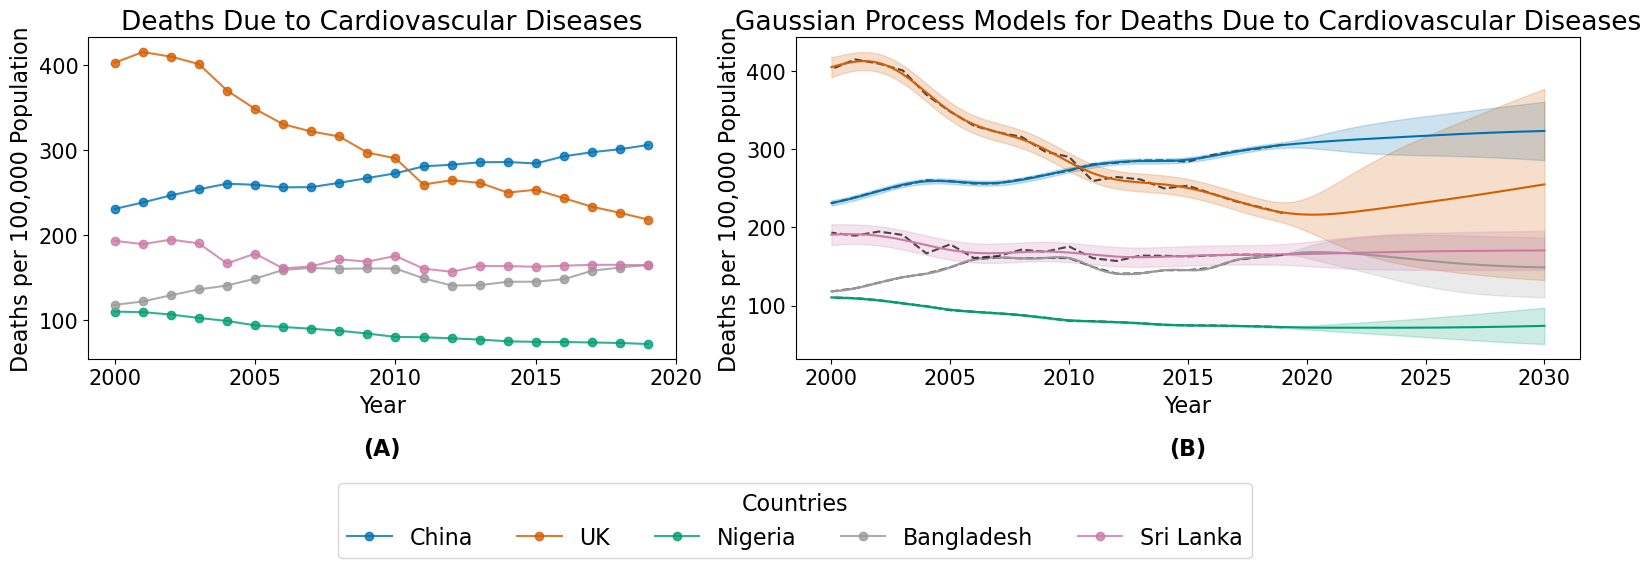

In [15]:
import warnings
warnings.filterwarnings("ignore")

disease = 'Cardiovascular diseases'

def plot_measurements(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[(df['Dim1'] == 'Both sexes') & (df['Dim2'] == disease) & (df['Location'] == country)]
    
    # Ensure 'Period' is of type string for merging
    filtered_data = filtered_data.copy()
    filtered_data['Period'] = filtered_data['Period'].astype(str)
    filtered_data_pln = pd.melt(filtered_data_pln, id_vars=['Country Name'], var_name='Year', value_name='Population')
    
    # Convert 'Year' to string for consistency in merging
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)
    
    # Merge population data with the main data
    merged_data = filtered_data.merge(filtered_data_pln, left_on=['Location', 'Period'], right_on=['Country Name', 'Year'])

    # Check if merged data is empty
    if merged_data.empty:
        print(f"No data for {country}")
        return

    # Calculate 'FactValueNumeric' per 100,000 population
    merged_data['FactValuePer100k'] = (merged_data['FactValueNumeric'] / merged_data['Population'].astype(float)) * 100000

    # Plot the results
    ax.plot(merged_data['Period'].astype(float), merged_data['FactValuePer100k'], color=color, label=f'{country}', marker='o', linestyle='-', alpha=0.8)

def plot_gp_regression(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[(df['Dim1'] == 'Both sexes') & (df['Dim2'] == disease) & (df['Location'] == country)]
    
    # Ensure 'Period' is of type string for merging
    filtered_data = filtered_data.copy()
    filtered_data['Period'] = filtered_data['Period'].astype(str)
    filtered_data_pln = pd.melt(filtered_data_pln, id_vars=['Country Name'], var_name='Year', value_name='Population')
    
    # Convert 'Year' to string for consistency in merging
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)
    
    # Merge population data with the main data
    merged_data = filtered_data.merge(filtered_data_pln, left_on=['Location', 'Period'], right_on=['Country Name', 'Year'])

    # Check if merged data is empty
    if merged_data.empty:
        print(f"No data for {country}")
        return

    # Calculate the new 'FactValueNumeric' per 100,000 population
    merged_data['FactValuePer100k'] = (merged_data['FactValueNumeric'] / merged_data['Population'].astype(float)) * 100000

    # Extract features and target variable
    features = merged_data['Period'].values.reshape(-1, 1).astype(float)  # Reshape to 2D array
    target = merged_data['FactValuePer100k']

    # Check if features and target are empty
    if features.size == 0 or target.size == 0:
        print(f"No data for {country}")
        return

    # Apply StandardScaler
    scaler_X = StandardScaler()
    X_processed = scaler_X.fit_transform(features)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1)).ravel()

    # Define the kernel for Gaussian Process
    
    irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=0.7, alpha=0.7)
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))
    ncd_kernel = matern_kernel + irregularities_kernel + noise_kernel

    # Fit the Gaussian Process model
    gp = GaussianProcessRegressor(kernel=ncd_kernel, n_restarts_optimizer=10, normalize_y=True)
    gp.fit(X_processed, y_scaled)

    # Generate synthetic data points for plotting
    X_test = np.linspace(features.min(), 2030, 1000).reshape(-1, 1)
    X_test_transformed = scaler_X.transform(X_test)
    y_synthetic_pred, y_synthetic_std = gp.predict(X_test_transformed, return_std=True)

    # Inverse transform predictions
    y_synthetic_pred_original = scaler_y.inverse_transform(y_synthetic_pred.reshape(-1, 1))
    y_synthetic_pred_upper = scaler_y.inverse_transform((y_synthetic_pred + 1.96 * y_synthetic_std).reshape(-1, 1))
    y_synthetic_pred_lower = scaler_y.inverse_transform((y_synthetic_pred - 1.96 * y_synthetic_std).reshape(-1, 1))

    
    # Plot the results with shortened country name in the label
    ax.plot(merged_data['Period'].astype(float), target, linestyle='--', color='black', alpha=0.7)  # Measurements
    ax.plot(X_test, y_synthetic_pred_original, color=color, label=country_short_names[country])
    ax.fill_between(X_test.ravel(), y_synthetic_pred_lower.ravel(), y_synthetic_pred_upper.ravel(), alpha=0.2, color=color)

# Define the countries and their colors
countries = ['China', 'United Kingdom of Great Britain and Northern Ireland', 'Nigeria', 'Bangladesh', 'Sri Lanka']
colors = ['#0072B2', '#D55E00', '#009E73', '#999999', '#CC79A7']

# Shortened country names for legend display
country_short_names = {
    'China': 'China',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Nigeria': 'Nigeria',
    'Bangladesh': 'Bangladesh',
    'Sri Lanka': 'Sri Lanka'
}

# Create subplots with the first plot taking 1/3 and the second taking 2/3 of the figure width
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 4]})
# Add annotation (a) under the first plot
ax1.text(0.5, -0.3, '(A)', transform=ax1.transAxes, fontsize=16, ha='center', fontweight='bold')

# Plot the first graph (measurements) on the first axis
for country, color in zip(countries, colors):
    plot_measurements(df, df2_P, country, ax1, color)

# Final touches for the first plot
ax1.set_xlabel('Year', fontsize=16)
ax1.set_ylabel('Deaths per 100,000 Population', fontsize=16)
ax1.set_title('Deaths Due to Cardiovascular Diseases', fontsize=19)
ax1.set_xticks(range(2000, 2021, 5))
ax1.tick_params(axis='both', labelsize=15)
# Plot the second graph (Gaussian Process) on the second axis
for country, color in zip(countries, colors):
    plot_gp_regression(df, df2_P, country, ax2, color)

# Final touches for the second plot
ax2.set_xlabel('Year', fontsize=16)
ax2.set_ylabel('Deaths per 100,000 Population', fontsize=16)
ax2.set_title('Gaussian Process Models for Deaths Due to Cardiovascular Diseases', fontsize=19)
#ax2.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
# Add annotation (b) under the second plot
ax2.tick_params(axis='both', labelsize=15)
ax2.text(0.5, -0.3, '(B)', transform=ax2.transAxes, fontsize=16, ha='center', fontweight='bold')

fig.legend(
    [plt.Line2D([0], [0], color=color, marker='o', linestyle='-', alpha=0.8) for color in colors],
    [country_short_names[country] for country in countries],
    loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(countries), fontsize=16, title='Countries', title_fontsize=16
)

plt.tight_layout()

plt.savefig('Figure_7_CV.tiff', dpi=300, bbox_inches='tight')
plt.savefig("Figure_7_CV.pdf", format="pdf",dpi=300)
plt.savefig("Figure_7_CV.png", dpi=300, bbox_inches='tight')
plt.show()


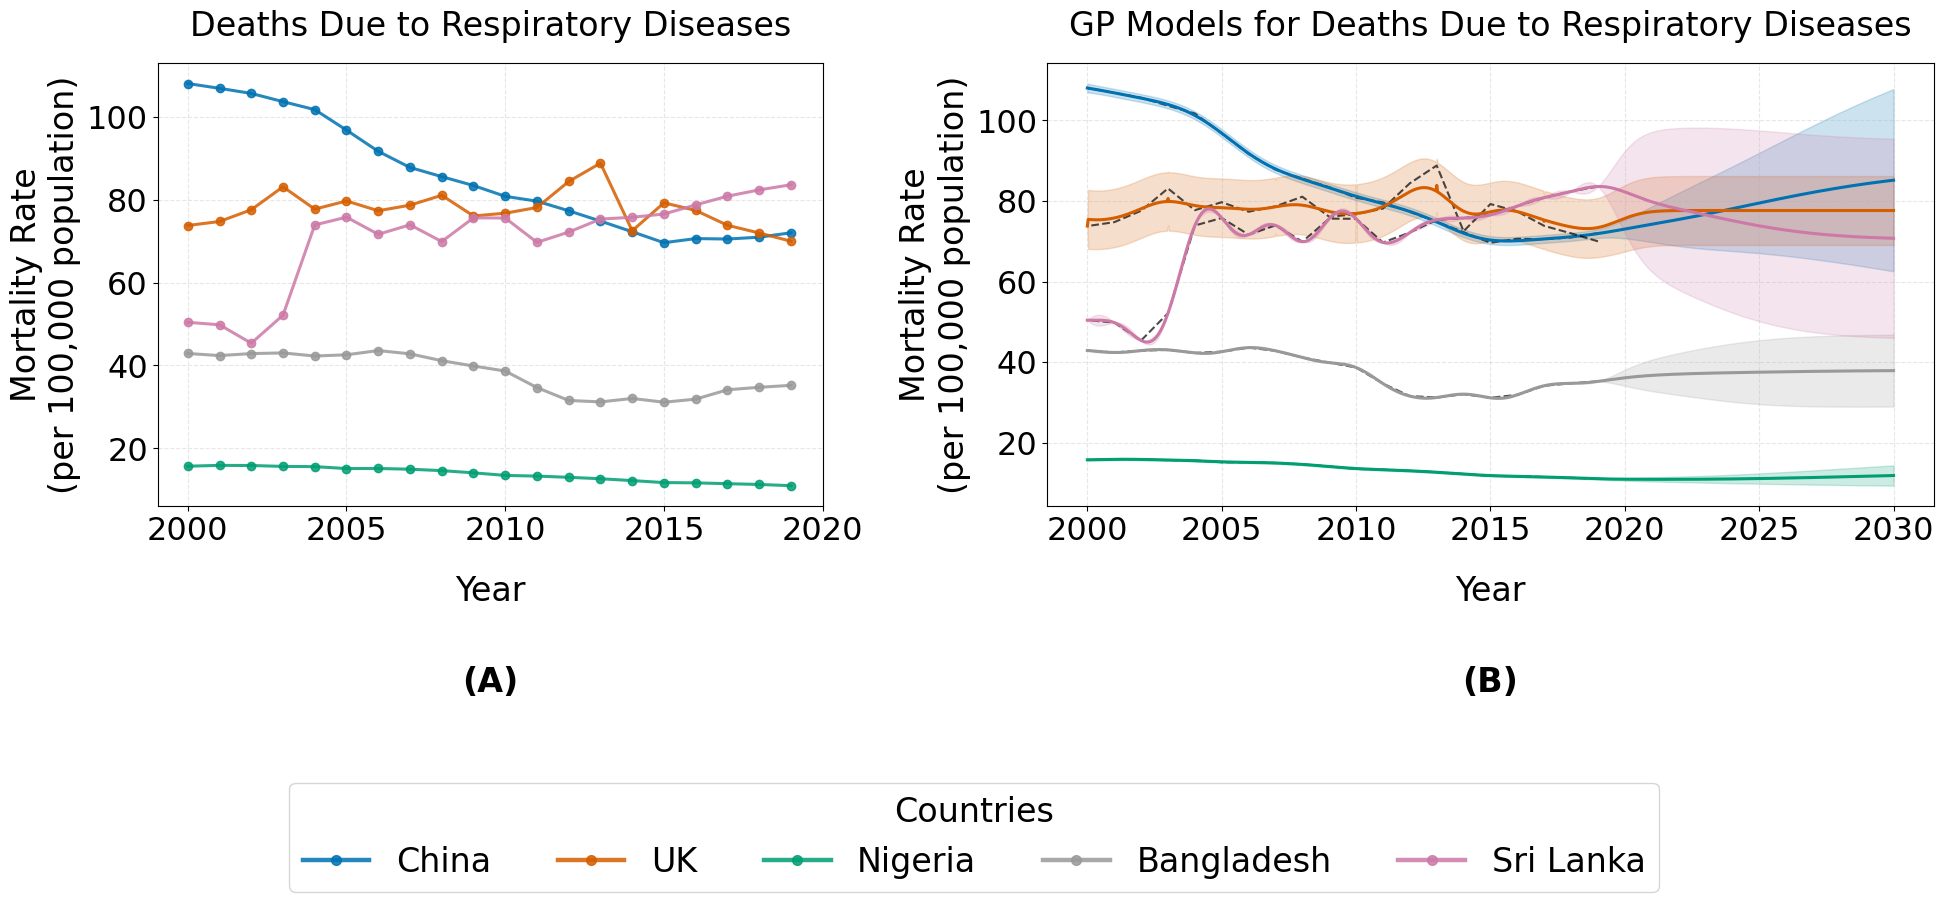

In [120]:
import warnings
warnings.filterwarnings("ignore")

disease = 'Respiratory diseases'

# Use larger default font sizes
plt.rcParams.update({
   'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 23,
    'ytick.labelsize': 23,
    'legend.fontsize': 24,
    'legend.title_fontsize': 24
})

def plot_measurements(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[
        (df['Dim1'] == 'Both sexes') &
        (df['Dim2'] == disease) &
        (df['Location'] == country)
    ].copy()

    filtered_data['Period'] = filtered_data['Period'].astype(str)

    filtered_data_pln = pd.melt(
        filtered_data_pln,
        id_vars=['Country Name'],
        var_name='Year',
        value_name='Population'
    )
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)

    merged_data = filtered_data.merge(
        filtered_data_pln,
        left_on=['Location', 'Period'],
        right_on=['Country Name', 'Year']
    )

    if merged_data.empty:
        print(f"No data for {country}")
        return

    merged_data['FactValuePer100k'] = (
        merged_data['FactValueNumeric'] /
        merged_data['Population'].astype(float)
    ) * 100000

    ax.plot(
        merged_data['Period'].astype(float),
        merged_data['FactValuePer100k'],
        color=color,
        label=country_short_names[country],
        marker='o',
        linestyle='-',
        linewidth=2.2,
        markersize=6,
        alpha=0.85
    )


def plot_gp_regression(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[
        (df['Dim1'] == 'Both sexes') &
        (df['Dim2'] == disease) &
        (df['Location'] == country)
    ].copy()

    filtered_data['Period'] = filtered_data['Period'].astype(str)

    filtered_data_pln = pd.melt(
        filtered_data_pln,
        id_vars=['Country Name'],
        var_name='Year',
        value_name='Population'
    )
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)

    merged_data = filtered_data.merge(
        filtered_data_pln,
        left_on=['Location', 'Period'],
        right_on=['Country Name', 'Year']
    )

    if merged_data.empty:
        print(f"No data for {country}")
        return

    merged_data['FactValuePer100k'] = (
        merged_data['FactValueNumeric'] /
        merged_data['Population'].astype(float)
    ) * 100000

    features = merged_data['Period'].values.reshape(-1, 1).astype(float)
    target = merged_data['FactValuePer100k']

    if features.size == 0 or target.size == 0:
        print(f"No data for {country}")
        return

    scaler_X = StandardScaler()
    X_processed = scaler_X.fit_transform(features)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1)).ravel()

    irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=0.7, alpha=0.7)
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    noise_kernel = (
        0.1**2 * RBF(length_scale=0.1) +
        WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))
    )

    ncd_kernel = matern_kernel + irregularities_kernel + noise_kernel

    gp = GaussianProcessRegressor(
        kernel=ncd_kernel,
        n_restarts_optimizer=10,
        normalize_y=True
    )

    gp.fit(X_processed, y_scaled)

    X_test = np.linspace(features.min(), 2030, 1000).reshape(-1, 1)
    X_test_transformed = scaler_X.transform(X_test)

    y_synthetic_pred, y_synthetic_std = gp.predict(
        X_test_transformed,
        return_std=True
    )

    y_synthetic_pred_original = scaler_y.inverse_transform(
        y_synthetic_pred.reshape(-1, 1)
    )

    y_synthetic_pred_upper = scaler_y.inverse_transform(
        (y_synthetic_pred + 1.96 * y_synthetic_std).reshape(-1, 1)
    )

    y_synthetic_pred_lower = scaler_y.inverse_transform(
        (y_synthetic_pred - 1.96 * y_synthetic_std).reshape(-1, 1)
    )

    ax.plot(
        merged_data['Period'].astype(float),
        target,
        linestyle='--',
        color='black',
        linewidth=1.5,
        alpha=0.7
    )

    ax.plot(
        X_test,
        y_synthetic_pred_original,
        color=color,
        label=country_short_names[country],
        linewidth=2.2
    )

    ax.fill_between(
        X_test.ravel(),
        y_synthetic_pred_lower.ravel(),
        y_synthetic_pred_upper.ravel(),
        alpha=0.2,
        color=color
    )


countries = [
    'China',
    'United Kingdom of Great Britain and Northern Ireland',
    'Nigeria',
    'Bangladesh',
    'Sri Lanka'
]

colors = ['#0072B2', '#D55E00', '#009E73', '#999999', '#CC79A7']

country_short_names = {
    'China': 'China',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Nigeria': 'Nigeria',
    'Bangladesh': 'Bangladesh',
    'Sri Lanka': 'Sri Lanka'
}


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(20, 8.5),
    gridspec_kw={'width_ratios': [3, 4]}
)

ax1.text(
    0.5, -0.42,
    '(A)',
    transform=ax1.transAxes,
    fontsize=24,
    ha='center',
    fontweight='bold'
)

for country, color in zip(countries, colors):
    plot_measurements(df, df2_P, country, ax1, color)

#ax1.set_xlabel('Year', fontweight='bold')
ax1.set_xlabel('Year', labelpad=20)
ax1.set_ylabel('Mortality Rate\n(per 100,000 population)')
ax1.set_title(
    'Deaths Due to Respiratory Diseases',
    pad=20
)
ax1.set_xticks(range(2000, 2021, 5))
ax1.tick_params(axis='both')
ax1.grid(True, linestyle='--', alpha=0.3)


for country, color in zip(countries, colors):
    plot_gp_regression(df, df2_P, country, ax2, color)

ax2.set_xlabel('Year', labelpad=20 )
ax2.set_ylabel('Mortality Rate\n(per 100,000 population)')
ax2.set_title(
    'GP Models for Deaths Due to Respiratory Diseases',
     pad=20
)
ax2.set_xticks(range(2000, 2031, 5))
ax2.tick_params(axis='both')
ax2.grid(True, linestyle='--', alpha=0.3)

ax2.text(
    0.5, -0.42,
    '(B)',
    transform=ax2.transAxes,
    fontsize=24,
    ha='center',
    fontweight='bold'
)


fig.legend(
    [plt.Line2D([0], [0], color=color, marker='o', linestyle='-', linewidth=3.2, markersize=7, alpha=0.85)
     for color in colors],
    [country_short_names[country] for country in countries],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(countries),
    title='Countries',
    frameon=True
)

plt.tight_layout()

plt.savefig('Figure_8_ResD.tiff', dpi=300, bbox_inches='tight')
#plt.savefig("Figure_8_ResD.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.savefig("Figure_8_ResD.png", dpi=300, bbox_inches='tight')

plt.show()

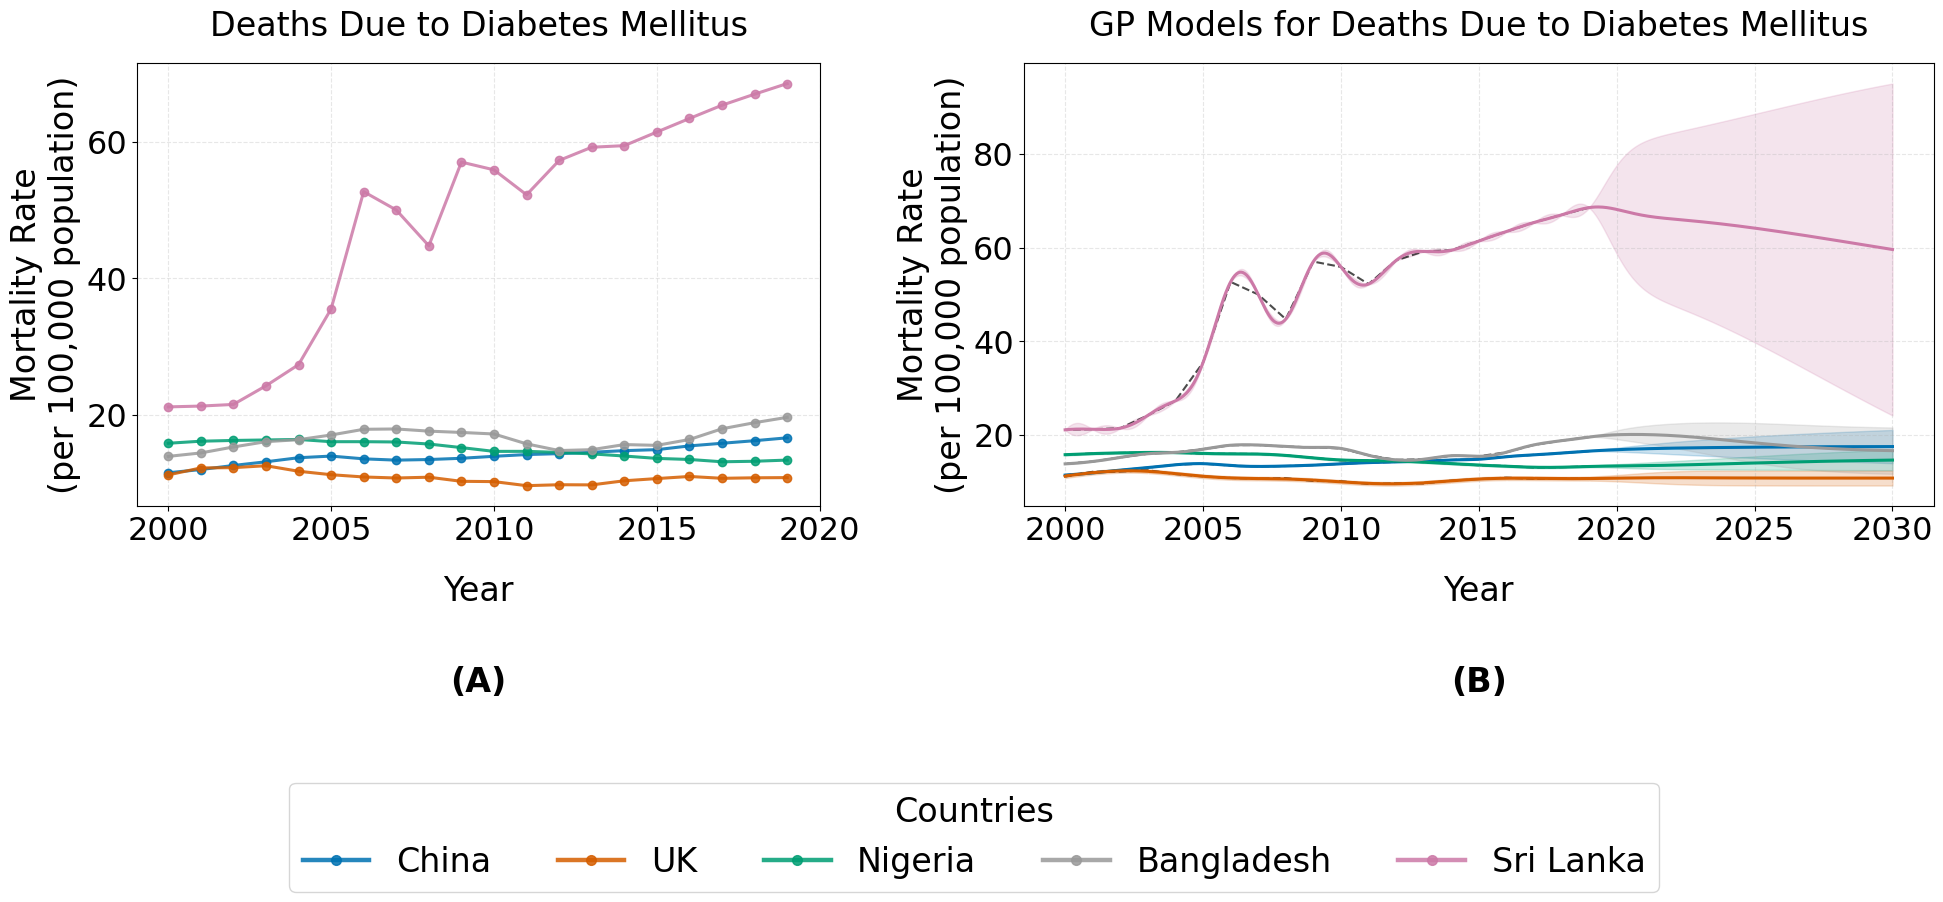

In [124]:
import warnings
warnings.filterwarnings("ignore")

disease = 'Diabetes mellitus'

# Use larger default font sizes
plt.rcParams.update({
   'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 23,
    'ytick.labelsize': 23,
    'legend.fontsize': 24,
    'legend.title_fontsize': 24
})

def plot_measurements(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[
        (df['Dim1'] == 'Both sexes') &
        (df['Dim2'] == disease) &
        (df['Location'] == country)
    ].copy()

    filtered_data['Period'] = filtered_data['Period'].astype(str)

    filtered_data_pln = pd.melt(
        filtered_data_pln,
        id_vars=['Country Name'],
        var_name='Year',
        value_name='Population'
    )
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)

    merged_data = filtered_data.merge(
        filtered_data_pln,
        left_on=['Location', 'Period'],
        right_on=['Country Name', 'Year']
    )

    if merged_data.empty:
        print(f"No data for {country}")
        return

    merged_data['FactValuePer100k'] = (
        merged_data['FactValueNumeric'] /
        merged_data['Population'].astype(float)
    ) * 100000

    ax.plot(
        merged_data['Period'].astype(float),
        merged_data['FactValuePer100k'],
        color=color,
        label=country_short_names[country],
        marker='o',
        linestyle='-',
        linewidth=2.2,
        markersize=6,
        alpha=0.85
    )


def plot_gp_regression(df, df_pop, country, ax, color):
    filtered_data_pln = df_pop[df_pop['Country Name'] == country]
    filtered_data = df[
        (df['Dim1'] == 'Both sexes') &
        (df['Dim2'] == disease) &
        (df['Location'] == country)
    ].copy()

    filtered_data['Period'] = filtered_data['Period'].astype(str)

    filtered_data_pln = pd.melt(
        filtered_data_pln,
        id_vars=['Country Name'],
        var_name='Year',
        value_name='Population'
    )
    filtered_data_pln['Year'] = filtered_data_pln['Year'].astype(str)

    merged_data = filtered_data.merge(
        filtered_data_pln,
        left_on=['Location', 'Period'],
        right_on=['Country Name', 'Year']
    )

    if merged_data.empty:
        print(f"No data for {country}")
        return

    merged_data['FactValuePer100k'] = (
        merged_data['FactValueNumeric'] /
        merged_data['Population'].astype(float)
    ) * 100000

    features = merged_data['Period'].values.reshape(-1, 1).astype(float)
    target = merged_data['FactValuePer100k']

    if features.size == 0 or target.size == 0:
        print(f"No data for {country}")
        return

    scaler_X = StandardScaler()
    X_processed = scaler_X.fit_transform(features)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1)).ravel()

    irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=0.7, alpha=0.7)
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    noise_kernel = (
        0.1**2 * RBF(length_scale=0.1) +
        WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))
    )

    ncd_kernel = matern_kernel + irregularities_kernel + noise_kernel

    gp = GaussianProcessRegressor(
        kernel=ncd_kernel,
        n_restarts_optimizer=10,
        normalize_y=True
    )

    gp.fit(X_processed, y_scaled)

    X_test = np.linspace(features.min(), 2030, 1000).reshape(-1, 1)
    X_test_transformed = scaler_X.transform(X_test)

    y_synthetic_pred, y_synthetic_std = gp.predict(
        X_test_transformed,
        return_std=True
    )

    y_synthetic_pred_original = scaler_y.inverse_transform(
        y_synthetic_pred.reshape(-1, 1)
    )

    y_synthetic_pred_upper = scaler_y.inverse_transform(
        (y_synthetic_pred + 1.96 * y_synthetic_std).reshape(-1, 1)
    )

    y_synthetic_pred_lower = scaler_y.inverse_transform(
        (y_synthetic_pred - 1.96 * y_synthetic_std).reshape(-1, 1)
    )

    ax.plot(
        merged_data['Period'].astype(float),
        target,
        linestyle='--',
        color='black',
        linewidth=1.5,
        alpha=0.7
    )

    ax.plot(
        X_test,
        y_synthetic_pred_original,
        color=color,
        label=country_short_names[country],
        linewidth=2.2
    )

    ax.fill_between(
        X_test.ravel(),
        y_synthetic_pred_lower.ravel(),
        y_synthetic_pred_upper.ravel(),
        alpha=0.2,
        color=color
    )


countries = [
    'China',
    'United Kingdom of Great Britain and Northern Ireland',
    'Nigeria',
    'Bangladesh',
    'Sri Lanka'
]

colors = ['#0072B2', '#D55E00', '#009E73', '#999999', '#CC79A7']

country_short_names = {
    'China': 'China',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'Nigeria': 'Nigeria',
    'Bangladesh': 'Bangladesh',
    'Sri Lanka': 'Sri Lanka'
}


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(20, 8.5),
    gridspec_kw={'width_ratios': [3, 4]}
)

ax1.text(
    0.5, -0.42,
    '(A)',
    transform=ax1.transAxes,
    fontsize=24,
    ha='center',
    fontweight='bold'
)

for country, color in zip(countries, colors):
    plot_measurements(df, df2_P, country, ax1, color)

#ax1.set_xlabel('Year', fontweight='bold')
ax1.set_xlabel('Year', labelpad=20)
ax1.set_ylabel('Mortality Rate\n(per 100,000 population)')
ax1.set_title(
    'Deaths Due to Diabetes Mellitus',
    pad=20
)
ax1.set_xticks(range(2000, 2021, 5))
ax1.tick_params(axis='both')
ax1.grid(True, linestyle='--', alpha=0.3)


for country, color in zip(countries, colors):
    plot_gp_regression(df, df2_P, country, ax2, color)

ax2.set_xlabel('Year', labelpad=20 )
ax2.set_ylabel('Mortality Rate\n(per 100,000 population)')
ax2.set_title(
    'GP Models for Deaths Due to Diabetes Mellitus',
     pad=20
)
ax2.set_xticks(range(2000, 2031, 5))
ax2.tick_params(axis='both')
ax2.grid(True, linestyle='--', alpha=0.3)

ax2.text(
    0.5, -0.42,
    '(B)',
    transform=ax2.transAxes,
    fontsize=24,
    ha='center',
    fontweight='bold'
)


fig.legend(
    [plt.Line2D([0], [0], color=color, marker='o', linestyle='-', linewidth=3.2, markersize=7, alpha=0.85)
     for color in colors],
    [country_short_names[country] for country in countries],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(countries),
    title='Countries',
    frameon=True
)

plt.tight_layout()

plt.savefig('Figure_10_DM.tiff', dpi=300, bbox_inches='tight')
#plt.savefig("Figure_8_ResD.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.savefig("Figure_10_DM.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# ============================================================
# Quantitative Evaluation of GPR Forecasting Performance
# Train: 2000–2014, Test: 2015–2019
# Metrics: MAE, RMSE, MAPE
# ============================================================


# -----------------------------
# Evaluation settings
# -----------------------------
TRAIN_END_YEAR = 2014
TEST_START_YEAR = 2015
TEST_END_YEAR = 2019

countries = [
    "China",
    "United Kingdom of Great Britain and Northern Ireland",
    "Nigeria",
    "Bangladesh",
    "Sri Lanka",
    "India",
    "South Africa"
]

diseases = [
    "Cardiovascular diseases",
    "Respiratory diseases",
    "Diabetes mellitus",
    "Malignant neoplasms"
]

genders = ["Both sexes", "Male", "Female"]


# -----------------------------
# Helper function: prepare country/disease/gender data
# -----------------------------
def prepare_ncd_series(df, df_pop, country, disease, gender):
    filtered_pop = df_pop[df_pop["Country Name"] == country]

    filtered_data = df[
        (df["Location"] == country) &
        (df["Dim2"] == disease) &
        (df["Dim1"] == gender)
    ].copy()

    if filtered_data.empty or filtered_pop.empty:
        return pd.DataFrame()

    filtered_data["Period"] = filtered_data["Period"].astype(str)

    pop_long = pd.melt(
        filtered_pop,
        id_vars=["Country Name"],
        var_name="Year",
        value_name="Population"
    )

    pop_long["Year"] = pop_long["Year"].astype(str)

    merged_data = filtered_data.merge(
        pop_long,
        left_on=["Location", "Period"],
        right_on=["Country Name", "Year"]
    )

    if merged_data.empty:
        return pd.DataFrame()

    merged_data["Population"] = merged_data["Population"].astype(float)
    merged_data["FactValueNumeric"] = merged_data["FactValueNumeric"].astype(float)

    merged_data["FactValuePer100k"] = (
        merged_data["FactValueNumeric"] / merged_data["Population"]
    ) * 100000

    merged_data["Period"] = merged_data["Period"].astype(int)

    merged_data = merged_data[["Period", "FactValuePer100k"]].dropna()
    merged_data = merged_data.sort_values("Period")

    return merged_data


# -----------------------------
# Helper function: define GPR kernel
# -----------------------------
def create_ncd_kernel():
    irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=0.7, alpha=0.7)
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))

    ncd_kernel = matern_kernel + irregularities_kernel + noise_kernel

    return ncd_kernel


# -----------------------------
# Helper function: safe MAPE
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# -----------------------------
# Main evaluation loop
# -----------------------------
evaluation_results = []

for country in countries:
    for disease in diseases:
        for gender in genders:

            data_series = prepare_ncd_series(
                df=df,
                df_pop=df2_P,
                country=country,
                disease=disease,
                gender=gender
            )

            if data_series.empty:
                continue

            train_data = data_series[data_series["Period"] <= TRAIN_END_YEAR]
            test_data = data_series[
                (data_series["Period"] >= TEST_START_YEAR) &
                (data_series["Period"] <= TEST_END_YEAR)
            ]

            if len(train_data) < 5 or len(test_data) < 1:
                continue

            X_train = train_data["Period"].values.reshape(-1, 1).astype(float)
            y_train = train_data["FactValuePer100k"].values

            X_test = test_data["Period"].values.reshape(-1, 1).astype(float)
            y_test = test_data["FactValuePer100k"].values

            # Fit scalers only on training data to avoid data leakage
            scaler_X = StandardScaler()
            X_train_scaled = scaler_X.fit_transform(X_train)
            X_test_scaled = scaler_X.transform(X_test)

            scaler_y = StandardScaler()
            y_train_scaled = scaler_y.fit_transform(
                y_train.reshape(-1, 1)
            ).ravel()

            # Fit GPR model
            gp = GaussianProcessRegressor(
                kernel=create_ncd_kernel(),
                n_restarts_optimizer=10,
                normalize_y=True,
                random_state=42
            )

            gp.fit(X_train_scaled, y_train_scaled)

            # Predict test years
            y_pred_scaled, y_std_scaled = gp.predict(
                X_test_scaled,
                return_std=True
            )

            y_pred = scaler_y.inverse_transform(
                y_pred_scaled.reshape(-1, 1)
            ).ravel()

            y_upper = scaler_y.inverse_transform(
                (y_pred_scaled + 1.96 * y_std_scaled).reshape(-1, 1)
            ).ravel()

            y_lower = scaler_y.inverse_transform(
                (y_pred_scaled - 1.96 * y_std_scaled).reshape(-1, 1)
            ).ravel()

            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mape = mean_absolute_percentage_error_safe(y_test, y_pred)

            coverage_95 = np.mean(
                (y_test >= y_lower) & (y_test <= y_upper)
            ) * 100

            evaluation_results.append({
                "Country": country,
                "Disease": disease,
                "Gender": gender,
                "Train years": f"2000–{TRAIN_END_YEAR}",
                "Test years": f"{TEST_START_YEAR}–{TEST_END_YEAR}",
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape,
                "95% PI Coverage (%)": coverage_95,
                "No. Train Points": len(train_data),
                "No. Test Points": len(test_data)
            })


# -----------------------------
# Convert results to table
# -----------------------------
evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df = evaluation_df.sort_values(
    by=["Country", "Disease", "Gender"]
).reset_index(drop=True)

evaluation_df.head()

In [20]:
# ============================================================
# Summary of model performance across all evaluated series
# ============================================================

summary_metrics = evaluation_df[
    ["MAE", "RMSE", "MAPE (%)", "95% PI Coverage (%)"]
].agg(["mean", "median", "std", "min", "max"])

summary_metrics

,MAE,RMSE,MAPE (%),95% PI Coverage (%)
mean,3.523640,4.157894,5.913114,78.333333
median,1.996085,2.251811,5.561224,100.000000
std,3.563802,4.226079,3.689782,30.451753
min,0.031011,0.038338,0.336575,0.000000
max,17.616313,21.865989,16.251743,100.000000


In [21]:
evaluation_df.to_csv("GPR_Evaluation_Results_2015_2019.csv", index=False)
summary_metrics.to_csv("GPR_Evaluation_Summary_2015_2019.csv")

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [24]:
# ==========================================================
# Performance Metrics by Disease
# ==========================================================

disease_results = (
    evaluation_df
    .groupby("Disease")[["MAE", "RMSE", "MAPE (%)"]]
    .mean()
    .round(3)
    .sort_values("MAPE (%)")
)

print("\nPerformance Metrics by Disease")
print(disease_results)

# Save table
disease_results.to_csv("Disease_Performance_Metrics.csv")

disease_results


Performance Metrics by Disease
                           MAE   RMSE  MAPE (%)
Disease                                        
Malignant neoplasms      3.314  3.878     5.127
Cardiovascular diseases  6.768  8.092     5.391
Respiratory diseases     2.204  2.518     5.732
Diabetes mellitus        1.808  2.145     7.402


,MAE,RMSE,MAPE (%)
Disease,,,
Malignant neoplasms,3.314,3.878,5.127
Cardiovascular diseases,6.768,8.092,5.391
Respiratory diseases,2.204,2.518,5.732
Diabetes mellitus,1.808,2.145,7.402


In [26]:
# ------------------------------------------------------------
# Standard GPR-RBF kernel
# ------------------------------------------------------------

def create_standard_rbf_kernel():
    standard_kernel = 1.0**2 * RBF(length_scale=1.0) + WhiteKernel(
        noise_level=0.1**2
    )
    return standard_kernel


# ------------------------------------------------------------
# Safe MAPE
# ------------------------------------------------------------

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if np.sum(mask) == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# ------------------------------------------------------------
# Metric function
# ------------------------------------------------------------

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = safe_mape(y_true, y_pred)

    return mae, rmse, mape



# ------------------------------------------------------------
# Main comparison loop
# ------------------------------------------------------------

comparison_results = []

for country in countries:
    for disease in diseases:
        for gender in genders:

            data_series = prepare_ncd_series(
                df=df,
                df_pop=df2_P,
                country=country,
                disease=disease,
                gender=gender
            )

            if data_series.empty:
                continue

            train_data = data_series[data_series["Period"] <= TRAIN_END_YEAR]

            test_data = data_series[
                (data_series["Period"] >= TEST_START_YEAR) &
                (data_series["Period"] <= TEST_END_YEAR)
            ]

            if len(train_data) < 5 or len(test_data) < 1:
                continue

            X_train = train_data["Period"].values.reshape(-1, 1).astype(float)
            y_train = train_data["FactValuePer100k"].values

            X_test = test_data["Period"].values.reshape(-1, 1).astype(float)
            y_test = test_data["FactValuePer100k"].values

            # ==================================================
            # 1. Linear Trend Regression
            # ==================================================

            linear_model = LinearRegression()
            linear_model.fit(X_train, y_train)
            y_pred_linear = linear_model.predict(X_test)

            mae, rmse, mape = calculate_metrics(y_test, y_pred_linear)

            comparison_results.append({
                "Country": country,
                "Disease": disease,
                "Gender": gender,
                "Model": "Linear Trend Regression",
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape
            })

           
            # ==================================================
            # 2. Standard GPR-RBF
            # ==================================================

            scaler_X = StandardScaler()
            X_train_scaled = scaler_X.fit_transform(X_train)
            X_test_scaled = scaler_X.transform(X_test)

            scaler_y = StandardScaler()
            y_train_scaled = scaler_y.fit_transform(
                y_train.reshape(-1, 1)
            ).ravel()

            standard_gpr = GaussianProcessRegressor(
                kernel=create_standard_rbf_kernel(),
                n_restarts_optimizer=10,
                normalize_y=True,
                random_state=42
            )

            standard_gpr.fit(X_train_scaled, y_train_scaled)

            y_pred_standard_scaled = standard_gpr.predict(X_test_scaled)

            y_pred_standard = scaler_y.inverse_transform(
                y_pred_standard_scaled.reshape(-1, 1)
            ).ravel()

            mae, rmse, mape = calculate_metrics(y_test, y_pred_standard)

            comparison_results.append({
                "Country": country,
                "Disease": disease,
                "Gender": gender,
                "Model": "Standard GPR-RBF",
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape
            })

            # ==================================================
            # 3. Proposed GPR Combined Kernel
            # ==================================================

            proposed_gpr = GaussianProcessRegressor(
                kernel=create_ncd_kernel(),
                n_restarts_optimizer=10,
                normalize_y=True,
                random_state=42
            )

            proposed_gpr.fit(X_train_scaled, y_train_scaled)

            y_pred_proposed_scaled, y_std_proposed_scaled = proposed_gpr.predict(
                X_test_scaled,
                return_std=True
            )

            y_pred_proposed = scaler_y.inverse_transform(
                y_pred_proposed_scaled.reshape(-1, 1)
            ).ravel()

            mae, rmse, mape = calculate_metrics(y_test, y_pred_proposed)

            comparison_results.append({
                "Country": country,
                "Disease": disease,
                "Gender": gender,
                "Model": "Proposed GPR Combined Kernel",
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape
            })


# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    by=["Country", "Disease", "Gender", "Model"]
).reset_index(drop=True)

comparison_df

,Country,Disease,Gender,Model,MAE,RMSE,MAPE (%)
0,Bangladesh,Cardiovascular diseases,Both sexes,Linear Trend Regression,7.065503,8.813169,4.716620
1,Bangladesh,Cardiovascular diseases,Both sexes,Proposed GPR Combined Kernel,8.901057,11.006507,5.523674
2,Bangladesh,Cardiovascular diseases,Both sexes,Standard GPR-RBF,10.895906,13.311475,6.766695
3,Bangladesh,Cardiovascular diseases,Female,Linear Trend Regression,1.513320,2.007678,2.124165
4,Bangladesh,Cardiovascular diseases,Female,Proposed GPR Combined Kernel,4.997544,6.125265,6.563603
...,...,...,...,...,...,...,...
247,United Kingdom of Great Britain and Northern I...,Respiratory diseases,Female,Proposed GPR Combined Kernel,3.323288,3.911800,9.652741
248,United Kingdom of Great Britain and Northern I...,Respiratory diseases,Female,Standard GPR-RBF,3.323373,3.911806,9.652959
249,United Kingdom of Great Britain and Northern I...,Respiratory diseases,Male,Linear Trend Regression,2.126087,2.622010,5.639206
250,United Kingdom of Great Britain and Northern I...,Respiratory diseases,Male,Proposed GPR Combined Kernel,1.577351,1.742636,4.130171


In [27]:
# ============================================================
# Overall Model Comparison Table
# ============================================================

overall_model_comparison = (
    comparison_df
    .groupby("Model")[["MAE", "RMSE", "MAPE (%)"]]
    .mean()
    .round(3)
    .sort_values("MAPE (%)")
)

print("\nOverall Model Comparison")
print(overall_model_comparison)

overall_model_comparison.to_csv("Overall_Model_Comparison.csv")

overall_model_comparison


Overall Model Comparison
                                MAE   RMSE  MAPE (%)
Model                                               
Proposed GPR Combined Kernel  3.524  4.158     5.913
Linear Trend Regression       3.953  4.378     6.944
Standard GPR-RBF              5.147  5.820     8.614


,MAE,RMSE,MAPE (%)
Model,,,
Proposed GPR Combined Kernel,3.524,4.158,5.913
Linear Trend Regression,3.953,4.378,6.944
Standard GPR-RBF,5.147,5.820,8.614


In [33]:
overall_model_comparison

,MAE,RMSE,MAPE (%)
Model,,,
Proposed GPR Combined Kernel,3.524,4.158,5.913
Linear Trend Regression,3.953,4.378,6.944
Standard GPR-RBF,5.147,5.820,8.614
